# The main goal: To predict the success of a new restaurant in europe based on TripAdvisor data set

##Importing Libraries

In [8]:
#%pip install -qq category_encoders

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math

# for ML process
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
import sklearn.metrics as metrics
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.model_selection import train_test_split
from sklearn import set_config # for column transformer
from sklearn.base import BaseEstimator, TransformerMixin # for custom (cuisine) transformer
from category_encoders import TargetEncoder # for target encoding
from sklearn.pipeline import Pipeline       # for target encoding
from sklearn.compose import ColumnTransformer # for pipeline transformer
from sklearn.impute import SimpleImputer, MissingIndicator # for missing values imputation






## Loading the data

In [10]:
# Load the initial dataset
initial_df = pd.read_csv("../data/raw/tripadvisor_european_restaurants.csv")
initial_df.head()

C:\Users\Psychologist\AppData\Local\Temp\ipykernel_7392\638981460.py:2: DtypeWarning: Columns (0: region) have mixed types. Specify dtype option on import or set low_memory=False.
  initial_df = pd.read_csv("../data/raw/tripadvisor_european_restaurants.csv")


,restaurant_link,restaurant_name,original_location,country,region,province,city,address,latitude,longitude,...,excellent,very_good,average,poor,terrible,food,service,value,atmosphere,keywords
0,g10001637-d10002227,Le 147,"[""Europe"", ""France"", ""Nouvelle-Aquitaine"", ""Ha...",France,Nouvelle-Aquitaine,Haute-Vienne,Saint-Jouvent,"10 Maison Neuve, 87510 Saint-Jouvent France",45.961674,1.169131,...,2.0,0.0,0.0,0.0,0.0,4.0,4.5,4.0,NaN,NaN
1,g10001637-d14975787,Le Saint Jouvent,"[""Europe"", ""France"", ""Nouvelle-Aquitaine"", ""Ha...",France,Nouvelle-Aquitaine,Haute-Vienne,Saint-Jouvent,"16 Place de l Eglise, 87510 Saint-Jouvent France",45.957040,1.205480,...,2.0,2.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2,g10002858-d4586832,Au Bout du Pont,"[""Europe"", ""France"", ""Centre-Val de Loire"", ""B...",France,Centre-Val de Loire,Berry,Rivarennes,"2 rue des Dames, 36800 Rivarennes France",46.635895,1.386133,...,3.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
3,g10002986-d3510044,Le Relais de Naiade,"[""Europe"", ""France"", ""Nouvelle-Aquitaine"", ""Co...",France,Nouvelle-Aquitaine,Correze,Lacelle,"9 avenue Porte de la Correze 19170, 19170 Lace...",45.642610,1.824460,...,1.0,0.0,0.0,0.0,0.0,4.5,4.5,4.5,NaN,NaN
4,g10022428-d9767191,Relais Du MontSeigne,"[""Europe"", ""France"", ""Occitanie"", ""Aveyron"", ""...",France,Occitanie,Aveyron,Saint-Laurent-de-Levezou,"route du Montseigne, 12620 Saint-Laurent-de-Le...",44.208860,2.960470,...,4.0,7.0,0.0,0.0,0.0,4.5,4.5,4.5,NaN,NaN


In [11]:
initial_df.columns

Index(['restaurant_link', 'restaurant_name', 'original_location', 'country',
       'region', 'province', 'city', 'address', 'latitude', 'longitude',
       'claimed', 'awards', 'popularity_detailed', 'popularity_generic',
       'top_tags', 'price_level', 'price_range', 'meals', 'cuisines',
       'special_diets', 'features', 'vegetarian_friendly', 'vegan_options',
       'gluten_free', 'original_open_hours', 'open_days_per_week',
       'open_hours_per_week', 'working_shifts_per_week', 'avg_rating',
       'total_reviews_count', 'default_language',
       'reviews_count_in_default_language', 'excellent', 'very_good',
       'average', 'poor', 'terrible', 'food', 'service', 'value', 'atmosphere',
       'keywords'],
      dtype='str')

In [12]:
initial_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1083397 entries, 0 to 1083396
Data columns (total 42 columns):
 #   Column                             Non-Null Count    Dtype  
---  ------                             --------------    -----  
 0   restaurant_link                    1083397 non-null  str    
 1   restaurant_name                    1083396 non-null  str    
 2   original_location                  1083397 non-null  str    
 3   country                            1083397 non-null  str    
 4   region                             1033074 non-null  str    
 5   province                           742765 non-null   str    
 6   city                               682712 non-null   str    
 7   address                            1083397 non-null  str    
 8   latitude                           1067607 non-null  float64
 9   longitude                          1067607 non-null  float64
 10  claimed                            1081555 non-null  str    
 11  awards                             

## Fill missing cities from initial_df original_location

In [13]:
# Ensure the 'original_location' column contains lists and 'city' exists
initial_df['city'] = initial_df.apply(lambda row: row['original_location'][3] if pd.isnull(row['city']) and len(row['original_location']) > 3 else row['city'], axis=1)

## Drop rows with less than 20 reviews
### Explanation:

#### This column served a dual purpose in our pipeline. We chose to use this column as a Data Quality Filter; we excluded all restaurants with fewer than 20 reviews to ensure the statistical stability and credibility of the avg_rating. A rating based on only 2-3 reviews is highly volatile and prone to outliers

In [14]:
# Set the threshold
min_reviews = 20

# Count rows before filtering
rows_before_threshold = initial_df.shape[0]

# Filter: Keep only restaurants with 20 or more reviews

df = initial_df[initial_df['total_reviews_count'] >= min_reviews]

# Count rows after filtering
rows_after_threshold = df.shape[0]
removed_count = rows_before_threshold - rows_after_threshold

print(f"Rows before threshold filtering: {rows_before_threshold}")
print(f"Rows after threshold filtering: {rows_after_threshold}")
print(f"Removed {removed_count} restaurants with fewer than {min_reviews} reviews.")

# Verification: Display the minimum value in the column
print(f"New minimum reviews count: {df['total_reviews_count'].min()}")

Rows before threshold filtering: 1083397
Rows after threshold filtering: 559169
Removed 524228 restaurants with fewer than 20 reviews.
New minimum reviews count: 20.0


# Check duplication

In [15]:
has_duplicates = df.duplicated().any()
print(f"Are there duplicate rows? {has_duplicates}")

Are there duplicate rows? False


#  Target Leakage & Post-Hoc Data to drop

## Explanation:

### the columns excellent, very_good, average, poor, terrible are the components of the avg_rating which is the target variable

In [16]:
columns_to_drop = [
    'excellent', 'very_good', 'average', 'poor', 'terrible'
]
df = df.drop(columns=columns_to_drop,)
df.shape

(559169, 37)



## Columns popularity_detailed, popularity_generic: TripAdvisor’s internal ranking scores. These are outcomes of high ratings, not predictors for a new establishment.

## The awards column: Awards are typically granted based on historical high performance and ratings, making them a clear predictor of the target variable.

## Columns total_reviews_count, reviews_count_in_default_language : Since our business goal is to predict the success of a new, non-existent restaurant, we cannot rely on the number of reviews, which is a post-launch performance metric.

In [17]:
columns_to_drop = [
    'popularity_detailed', 'popularity_generic', 'awards', 'total_reviews_count', 'reviews_count_in_default_language'
]
df = df.drop(columns=columns_to_drop,)
df.shape

(559169, 32)

# Correlation matrix for suspected features that related to the target variable

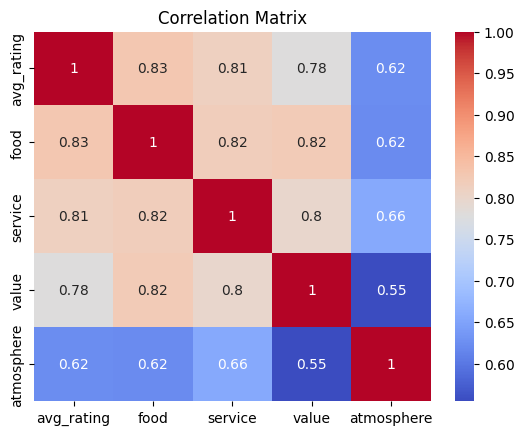

In [18]:
correlation_matrix = df[['avg_rating', 'food', 'service', 'value','atmosphere']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Based on the correlation matrix:

## Columns food, service, value are highly correlated to the target variable - and as such are dropped

## Even though the column atmosphere is not highly correlated, we found it's based on users rating, which describe outcome of high ratings, not predictor for a new establishment.

In [19]:
columns_to_drop = [
    'food', 'service', 'value', 'atmosphere'
]
df = df.drop(columns=columns_to_drop,)
df.shape

(559169, 28)

## Check Null values

In [20]:
df.isnull().sum()

restaurant_link                 0
restaurant_name                 0
original_location               0
country                         0
region                      22916
province                   162102
city                            0
address                         0
latitude                     1558
longitude                    1558
claimed                       946
top_tags                      437
price_level                  5906
price_range                369118
meals                      154065
cuisines                    24854
special_diets              236770
features                   357716
vegetarian_friendly             0
vegan_options                   0
gluten_free                     0
original_open_hours        163481
open_days_per_week         163481
open_hours_per_week        163481
working_shifts_per_week    163481
avg_rating                     79
default_language                0
keywords                   461834
dtype: int64

# Based on NULL check:

## Price_range is more than 60% NULL and we can extract the same information from the column price_level which is approximately 1% NULL

## Features column is more than 60% NULL and often overlap with existing cuisine/meal types.

## avg_rating - remove the 79 rows with NULL values (this is the target value..)

In [21]:
# Drop rows where the target 'avg_rating' is NaN
df = df.dropna(subset=['avg_rating'])

# Verify that target is clean
print(f"Target is now clean. Remaining rows: {len(df)}")

Target is now clean. Remaining rows: 559090


In [22]:
columns_to_drop = [
    'price_range','features'
]
df = df.drop(columns=columns_to_drop,)
df.shape

(559090, 26)

## Feature Engineering: New Strategic Variables

---

### 1. Cuisine Count (The Diversity Metric)

* **Logic:** Calculates the total number of cuisines listed for a single establishment.
* **Rationale:** This feature serves as a proxy for the restaurant's **operational complexity and market positioning**.
* **Predictive Value:** Establishments with a high cuisine count are often "tourist-friendly" or generic venues trying to cater to everyone. In contrast, a low cuisine count usually indicates a specialized, focused kitchen. These two styles typically exhibit very different rating distributions in the TripAdvisor ecosystem.

### 2. Is Chain (The Brand Factor)

* **Logic:** A binary indicator identifying whether a restaurant’s name appears multiple times across the dataset (different locations or cities).
* **Rationale:** To distinguish between **standardized franchises** and **independent local businesses**.
* **Predictive Value:** Chains (like McDonald's or Starbucks) benefit from brand consistency; customers have pre-set expectations, leading to "stable" but often middle-of-the-road ratings. Independent restaurants are "high-risk, high-reward"—they show much higher variance in their `avg_rating`, providing a critical signal for the model to distinguish between a unique local gem and a generic chain.



In [23]:
# is_chain feature engineering:

# 1. Count occurrences of each restaurant name
# We convert names to lowercase to ensure 'McDonalds' and 'mcdonalds' are treated the same
name_counts = df['restaurant_name'].str.lower().value_counts()

# 2. Identify names that appear more than once
chain_names = name_counts[name_counts > 1].index

# 3. Create the binary is_chain feature (1 if it's a chain, 0 otherwise)
df['is_chain'] = df['restaurant_name'].str.lower().isin(chain_names).astype(int)

# Optional: Verification
print(f"Number of restaurants identified as chains: {df['is_chain'].sum()}")
print(df[['restaurant_name', 'is_chain']].head())

Number of restaurants identified as chains: 153953
             restaurant_name  is_chain
0                     Le 147         1
3        Le Relais de Naiade         0
5  L'Auberge Du Vieux Crozet         0
6     Cafe Restaurant NouLou         0
7                  L'entre 2         1


In [24]:
# cuisine_count feature engineering:

# 1. Fill missing values with an empty string to avoid errors during splitting
# 2. Split the string by comma and space ', '
# 3. Calculate the length of the resulting list
# If the original value was NaN or empty, the count will be 0
df['cuisine_count'] = df['cuisines'].fillna('').apply(lambda x: len(x.split(', ')) if x != '' else 0)

# Optional: Verification to see the distribution
print(f"Average number of cuisines per restaurant: {df['cuisine_count'].mean():.2f}")
print(df[['cuisines', 'cuisine_count']].head())

Average number of cuisines per restaurant: 2.61
           cuisines  cuisine_count
0            French              1
3            French              1
5            French              1
6  French, European              2
7  French, European              2


# Drop overlap features that cause redundant information:

## Geospatial Granularity
We prioritized City and Country to maintain a manageable number of features while avoiding overfitting to specific addresses.

* latitude, longitude: GPS coordinates provide too much precision for a general rating model and can lead to overfitting on specific street corners.
* address, original_location: High-cardinality text data that is difficult to encode and mostly unique to each row.
* region, province: Redundant with city and country. Using too many levels of geographic hierarchy introduces multicollinearity.

## Redundancy & Multicollinearity

*   **`top_tags`**: Redundant information. Most keywords found here (e.g., "Italian", "Vegetarian") are already extracted into the `cuisines` or dietary binary columns.
*   **`special_diets`**: The specific dietary needs are already represented by more precise binary features: `vegetarian_friendly`, `vegan_options`, and `gluten_free`.
*   **`original_open_hours`**: Raw text data that was processed into structured features like `open_hours_per_week` and `working_shifts_per_week`.

## Irrelevant Metadata & Unique Identifiers
*These features do not provide any generalizable predictive power.*

*   **`restaurant_name`**: A unique identifier. While a name might carry brand weight, it does not provide a generalizable pattern for the model to learn.
*   **`restaurant_link`**: Metadata used for data scraping and web navigation, irrelevant to statistical modeling.

## Unstructured/Low-Variance Data
 * keywords: This column often contain sparse, unstructured text or descriptions that require heavy NLP processing and often overlap with existing cuisine/meal types.

In [25]:
# Define the list of columns to drop
columns_to_drop = [
    'keywords', 'special_diets',
    'latitude', 'longitude', 'original_location', 'region',
    'province', 'address', 'restaurant_name', 'original_open_hours',
    'top_tags', 'restaurant_link'
]


df = df.drop(columns=columns_to_drop)
df.shape




(559090, 16)

In [26]:
df.columns

Index(['country', 'city', 'claimed', 'price_level', 'meals', 'cuisines',
       'vegetarian_friendly', 'vegan_options', 'gluten_free',
       'open_days_per_week', 'open_hours_per_week', 'working_shifts_per_week',
       'avg_rating', 'default_language', 'is_chain', 'cuisine_count'],
      dtype='str')

## Converting Y,N Values for ['vegetarian_friendly', 'vegan_options', 'gluten_free'] to 0,1

In [27]:
#Check if there are NaN values
df[['vegetarian_friendly', 'vegan_options', 'gluten_free']].value_counts(dropna=False).reset_index()

,vegetarian_friendly,vegan_options,gluten_free,count
0,N,N,N,237881
1,Y,N,N,144569
2,Y,Y,Y,78856
3,Y,Y,N,50844
4,Y,N,Y,33362
5,N,N,Y,9730
6,N,Y,N,3095
7,N,Y,Y,753


In [28]:
# Define the columns to convert
binary_cols = ['vegetarian_friendly', 'vegan_options', 'gluten_free']

# Map 'N' to 0 and 'Y' to 1
# We apply the change directly to the dataframe
df[binary_cols] = df[binary_cols].replace({'N': 0, 'Y': 1})

# Verification: Display the first few rows and value counts to confirm the change
print("Conversion complete. New values:")
print(df[binary_cols].value_counts().reset_index())

# Check data types to ensure they are now numeric
print("\nNew column types:")
print(df[binary_cols].dtypes)

Conversion complete. New values:
   vegetarian_friendly  vegan_options  gluten_free   count
0                    0              0            0  237881
1                    1              0            0  144569
2                    1              1            1   78856
3                    1              1            0   50844
4                    1              0            1   33362
5                    0              0            1    9730
6                    0              1            0    3095
7                    0              1            1     753

New column types:
vegetarian_friendly    object
vegan_options          object
gluten_free            object
dtype: object


## Claimed - transforming to binary values

In [29]:
df["claimed"] = df["claimed"].map({
    "Unclaimed": 0,
    "Claimed": 1
})

In [30]:
print("NULL values in claimed:" ,df.claimed.isnull().sum())
print("Non-NULL values in claimed:" ,df.claimed.value_counts())

NULL values in claimed: 946
Non-NULL values in claimed: claimed
1.0    358444
0.0    199700
Name: count, dtype: int64


## Price level - transforming to ordinal


In [31]:
# Mapping price labels while preserving original NaNs
price_map = {
    '€': 1,
    '€€-€€€': 2,
    '€€€€': 3
}

# Map only the existing strings; values not in the map (like NaN) will remain NaN
df['price_level'] = df['price_level'].map(price_map)

print("Price Level conversion complete. Unique values:", df['price_level'].unique())

Price Level conversion complete. Unique values: [ 1.  2.  3. nan]


# Check default_language column values

In [32]:
df.default_language.value_counts()

default_language
English          487692
All languages     71398
Name: count, dtype: int64

# Handling default_language values:

## all languages = 1

## English = 0

In [33]:
df["default_language"] = df["default_language"].map({
    "English": 0,
    "All languages": 1
})
# Rename the column to 'all_languages'
df.rename(columns={"default_language": "all_languages"}, inplace=True)

## meals

In [34]:
# Split and explode into individual values
unique_meals = df['meals'].dropna().str.split(', ').explode()

# Get unique categories
unique_categories = unique_meals.unique()

print(f"Number of unique meal categories: {len(unique_categories)}")
print(unique_categories)

Number of unique meal categories: 6
<StringArray>
['Lunch', 'Dinner', 'Drinks', 'After-hours', 'Brunch', 'Breakfast']
Length: 6, dtype: str


Distribution of Meal Categories (Exploded):
             Quantity  Percentage (%)
meals                                
Dinner         339845           34.13
Lunch          332495           33.39
Breakfast       96871            9.73
After-hours     77067            7.74
Drinks          74785            7.51
Brunch          74764            7.51


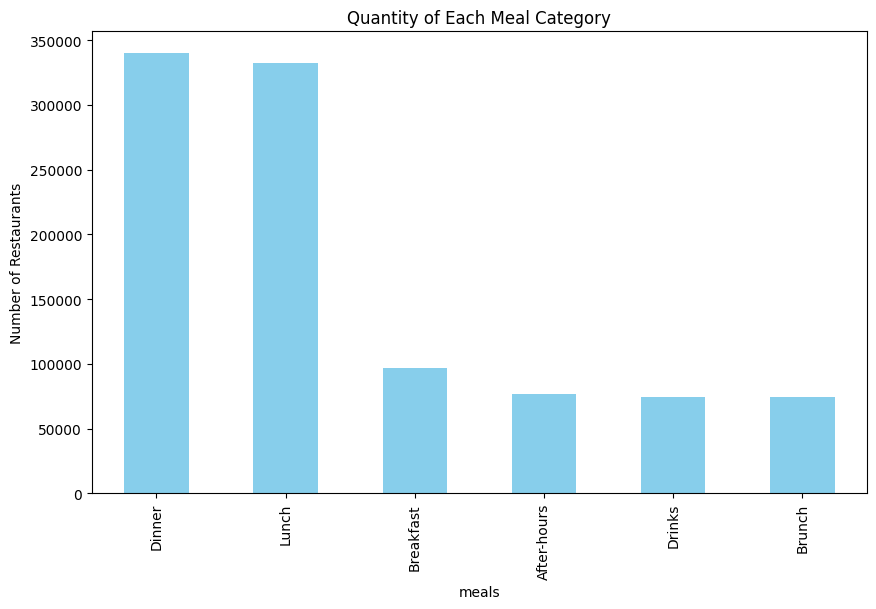

In [35]:
# 1. Split the comma-separated strings into lists and explode them into individual rows
# This ensures each meal type (e.g., 'Breakfast') is counted separately
exploded_meals = df['meals'].str.split(', ').explode()

# 2. Calculate absolute counts for each meal category
meal_counts = exploded_meals.value_counts()

# 3. Calculate percentages (relative frequency) and multiply by 100
meal_percentages = exploded_meals.value_counts(normalize=True) * 100

# 4. Combine counts and percentages into a single distribution DataFrame
meal_distribution = pd.DataFrame({
    'Quantity': meal_counts,
    'Percentage (%)': meal_percentages
})

# 5. Round the percentages for better readability
meal_distribution['Percentage (%)'] = meal_distribution['Percentage (%)'].round(2)

# Display the results
print("Distribution of Meal Categories (Exploded):")
print(meal_distribution)

# Optional: Visualize the distribution
import matplotlib.pyplot as plt
meal_distribution['Quantity'].plot(kind='bar', figsize=(10, 6), color='skyblue')
plt.title('Quantity of Each Meal Category')
plt.ylabel('Number of Restaurants')
plt.show()

In [36]:
# Create NA indicator BEFORE filling
df['NA_meals'] = df['meals'].isna().astype(int)

# Replace NaN with empty string so get_dummies works cleanly
meals_dummies = df['meals'].fillna('').str.get_dummies(sep=', ')
# Merge back
df = pd.concat([df, meals_dummies], axis=1)

# Drop original column
df = df.drop(columns=['meals'])

df.head()

,country,city,claimed,price_level,cuisines,vegetarian_friendly,vegan_options,gluten_free,open_days_per_week,open_hours_per_week,...,all_languages,is_chain,cuisine_count,NA_meals,After-hours,Breakfast,Brunch,Dinner,Drinks,Lunch
0,France,Saint-Jouvent,1.0,1.0,French,0,0,0,NaN,NaN,...,0,1,1,0,0,0,0,1,0,1
3,France,Lacelle,1.0,1.0,French,0,0,0,NaN,NaN,...,0,0,1,0,0,0,0,1,0,1
5,France,Le Crozet,1.0,2.0,French,0,0,0,7.0,53.5,...,1,0,1,0,0,0,0,1,1,1
6,France,Saint-Denis,1.0,2.0,"French, European",0,0,0,5.0,30.0,...,0,0,2,0,0,0,0,1,0,1
7,France,Saint-Denis,1.0,2.0,"French, European",1,0,0,6.0,24.0,...,0,1,2,1,0,0,0,0,0,0


## Create NA indicator for working_hours: (explanations ahead)


In [37]:
# Create NA indicator BEFORE filling
df['NA_working_hours'] = df['open_hours_per_week'].isna().astype(int)

## transform the target variable into binary values

In [38]:
df["great_restaurant"] = (df["avg_rating"] > 4).astype(int)

In [39]:
df['great_restaurant'].value_counts(normalize=True) * 100

great_restaurant
0    60.278131
1    39.721869
Name: proportion, dtype: float64

## Prepare the data for Encoding

### Our process: split the data for 70-15-15 between train,validation and test set


### Validation Strategy



> **Model Validation Strategy: Hold-out Set Selection**
> * **Dataset Scale:** Given the large volume of data (approx. 520,000 observations), a dedicated 15% Validation (Dev) set provides a robust statistical sample (approx. 78,000 rows) for performance estimation.
> * **Computational Efficiency:** Utilizing a fixed Dev set significantly accelerates hyperparameter tuning and model selection compared to K-Fold Cross-Validation, which would require training the model multiple times per iteration.
> * **Statistical Stability:** At this scale, the variance between different folds in Cross-Validation is negligible. A single large validation set is sufficient to represent the general population and ensure reliable results.
> * **Structural Integrity:** This 70-15-15 split maintains a strict "Blind Test" protocol, ensuring the final Test set remains completely untouched until the final evaluation.


In [40]:
X = df.drop(columns=['great_restaurant', 'avg_rating'])
y = df['great_restaurant']

In [41]:
# Step 1: Split the original data into a Temporary Set (85%) and the final Test Set (15%)
# We use random_state for reproducibility
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# Step 2: Split the Temporary Set into Train (70% of total) and Dev/Validation (15% of total)
# Since X_temp is 85% of the original, to get 15% of the original, we need:
# 15 / 85 ≈ 0.1765
X_train, X_dev, y_train, y_dev = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42
)

# --- Verification ---
print(f"Train set: {len(X_train)} rows ({len(X_train)/len(X)*100:.0f}%)")
print(f"Dev set:   {len(X_dev)} rows ({len(X_dev)/len(X)*100:.0f}%)")
print(f"Test set:  {len(X_test)} rows ({len(X_test)/len(X)*100:.0f}%)")

Train set: 391348 rows (70%)
Dev set:   83878 rows (15%)
Test set:  83864 rows (15%)


# First, we will check the distribution of the great_restaurant column

C:\Users\Psychologist\AppData\Local\Temp\ipykernel_7392\228826554.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df['great_restaurant'], palette=['#EC7063', '#5DADE2'])


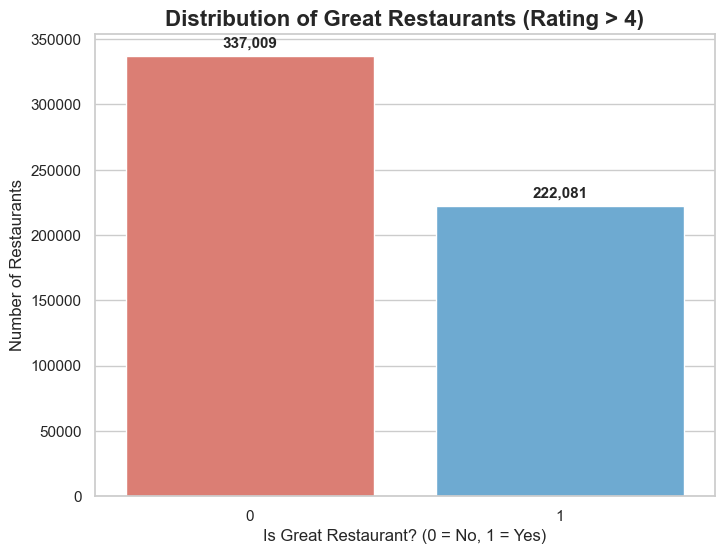

In [42]:
# Set the visual style
sns.set_theme(style="whitegrid")

# Create the figure
plt.figure(figsize=(8, 6))

# Generate a Count Plot for the binary column
# palette: sets specific colors for 0 (Red-ish) and 1 (Blue-ish)
ax = sns.countplot(x=df['great_restaurant'], palette=['#EC7063', '#5DADE2'])

# Add titles and axis labels
plt.title('Distribution of Great Restaurants (Rating > 4)', fontsize=16, fontweight='bold')
plt.xlabel('Is Great Restaurant? (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Number of Restaurants', fontsize=12)

# Optional: Add count values on top of each bar for better readability
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

# Display the plot
plt.show()

## Target Encoding


> **Geographic Feature Encoding (City & Country)**
> To handle the high cardinality of the `city` and `country` features, we implemented **Target Encoding (Mean Encoding)**. This technique transforms categorical labels into numerical values based on the mean of the target variable (`great_restaurant`) within each group. By including both levels, the model captures local urban trends via the city-level data while maintaining statistical stability through the country-level "anchor," which provides a reliable baseline for cities with fewer observations. To ensure model integrity and prevent **Data Leakage**, the encoding was calculated strictly on the training set and applied to the test set using a **Smoothing** technique to mitigate overfitting.

## Check Cuisine column before putting it all together into pipeline

# Cuisine column - Categorical tranformation:



> **Cuisine Categorization and the Unified 'Other' Feature**
> The `CuisineTransformer` employs a strategic mapping logic designed to consolidate a high-cardinality list of culinary styles into broad, predictive categories. A central component of this logic is the aggregation of rare or unrecognized cuisines into a single **'Other'** category. By utilizing a final `else` condition within the mapping function, any cuisine that does not fall into the primary predefined groups (e.g., Italian, Asian, or Mediterranean) is assigned the 'Other' label. This ensures that when the `get_dummies` operation is performed, all such entries are merged into one unique binary column, preventing the creation of redundant or sparse features.
>
> Furthermore, the transformer maintains a critical distinction between **'Other'** and **'NA_cuisines'**. While the 'Other' column represents restaurants with known but non-primary culinary classifications, the 'NA_cuisines' indicator serves as a dedicated feature for observations where data was entirely missing (**NaN**). This dual-layered approach ensures that the model can differentiate between a lack of information and a rare culinary style, providing a clean, consistent, and robust feature set for both the training and testing phases.

In [43]:
# --- 1. Class Definition (CuisineTransformer) ---
class CuisineTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.categories_ = None

    def map_cuisine(self, cuisine):
        if not cuisine or pd.isna(cuisine): return 'Other'
        cuisine = str(cuisine).lower()

        if cuisine in ['italian', 'pizza', 'sicilian', 'tuscan', 'southern-italian', 'northern-italian', 'central-italian', 'neapolitan']:
            return 'Italian'
        elif cuisine in ['french', 'spanish', 'british', 'german', 'dutch', 'belgian', 'austrian', 'scandinavian', 'polish', 'swedish', 'danish', 'czech']:
            return 'European'
        elif cuisine in ['greek', 'turkish', 'mediterranean', 'lebanese', 'israeli']:
            return 'Mediterranean'
        elif cuisine in ['chinese', 'japanese', 'sushi', 'korean', 'thai', 'vietnamese', 'indian', 'pakistani', 'bangladeshi', 'indonesian']:
            return 'Asian'
        elif cuisine in ['american', 'fast food', 'diner', 'steakhouse']:
            return 'American'
        elif cuisine in ['mexican', 'brazilian', 'argentinian', 'peruvian', 'caribbean']:
            return 'Latin American'
        elif cuisine in ['moroccan', 'ethiopian', 'egyptian', 'african']:
            return 'African & Middle Eastern'
        elif cuisine in ['cafe', 'bar', 'pub', 'wine bar', 'gastropub']:
            return 'Dining Style'
        elif cuisine in ['seafood', 'barbecue', 'grill', 'healthy']:
            return 'Specialty'
        return 'Other'

    def fit(self, X, y=None):
        processed = X.fillna('').apply(lambda x: ', '.join(set(map(self.map_cuisine, x.split(', ')))) if x else 'Other')
        dummies = processed.str.get_dummies(sep=', ')
        self.categories_ = dummies.columns.tolist()
        return self

    def transform(self, X):
        na_indicator = X.isna().astype(int).values.reshape(-1, 1)
        processed = X.fillna('').apply(lambda x: ', '.join(set(map(self.map_cuisine, x.split(', ')))) if x else 'Other')
        dummies = processed.str.get_dummies(sep=', ')

        for col in self.categories_:
            if col not in dummies.columns:
                dummies[col] = 0

        final_df = dummies[self.categories_].copy()
        final_df['NA_cuisines'] = na_indicator
        return final_df

    def get_feature_names_out(self, input_features=None):
      return np.array(self.categories_ + ['NA_cuisines'])


## Check missing values

In [44]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 391348 entries, 223851 to 223986
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   country                  391348 non-null  str    
 1   city                     391348 non-null  str    
 2   claimed                  390670 non-null  float64
 3   price_level              387254 non-null  float64
 4   cuisines                 374045 non-null  str    
 5   vegetarian_friendly      391348 non-null  object 
 6   vegan_options            391348 non-null  object 
 7   gluten_free              391348 non-null  object 
 8   open_days_per_week       276804 non-null  float64
 9   open_hours_per_week      276804 non-null  float64
 10  working_shifts_per_week  276804 non-null  float64
 11  all_languages            391348 non-null  int64  
 12  is_chain                 391348 non-null  int64  
 13  cuisine_count            391348 non-null  int64  
 14  NA_meals       

<Axes: >

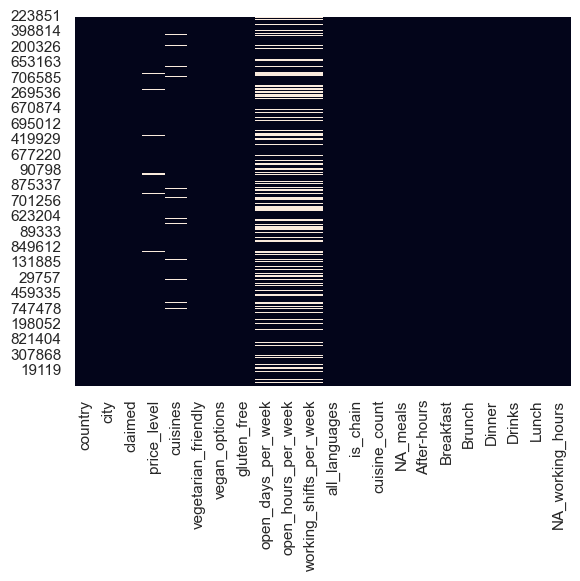

In [45]:
sns.heatmap(X_train.isna(), cbar=False)

In [47]:
# keep only columns that have at least one NA
df_na = X_train.loc[:, X_train.isna().any()]
df_na.isna().corr()

,claimed,price_level,cuisines,open_days_per_week,open_hours_per_week,working_shifts_per_week
claimed,1.000000,-0.001868,0.193692,0.000750,0.000750,0.000750
price_level,-0.001868,1.000000,0.033107,0.057887,0.057887,0.057887
cuisines,0.193692,0.033107,1.000000,0.051376,0.051376,0.051376
open_days_per_week,0.000750,0.057887,0.051376,1.000000,1.000000,1.000000
open_hours_per_week,0.000750,0.057887,0.051376,1.000000,1.000000,1.000000
working_shifts_per_week,0.000750,0.057887,0.051376,1.000000,1.000000,1.000000


## Creating the pipeline for smooth transformation

In [48]:
# Set global configuration to output pandas DataFrames
set_config(transform_output="pandas")

# --- 1. Custom Transformer for Group Median Imputation ---
class GroupMedianImputer(BaseEstimator, TransformerMixin):
    def __init__(self, group_col, target_col):
        self.group_col = group_col
        self.target_col = target_col
        self.group_medians_ = None
        self.global_median_ = None

    def fit(self, X, y=None):
        # Calculate median per group from the training set
        self.group_medians_ = X.groupby(self.group_col)[self.target_col].median()
        # Fallback global median for new groups in dev/test
        self.global_median_ = X[self.target_col].median()
        return self

    def transform(self, X):
        X = X.copy()
        # Map group medians to the target column
        X[self.target_col] = X[self.target_col].fillna(X[self.group_col].map(self.group_medians_))
        # Final safety fill using global median
        X[self.target_col] = X[self.target_col].fillna(self.global_median_)
        return X[[self.target_col]]

# --- 2. Helper Functions ---
def transform_to_df(transformer, X_input):
    """
    Cleans column names and removes duplicate logic.
    """
    data_transformed = transformer.transform(X_input)

    new_cols = []
    for col in data_transformed.columns:
        # Extract original feature name by removing any transformer prefixes
        clean_name = col.split('__')[-1]
        if 'hours_indicators' in col:
            new_cols.append(f"{clean_name}_NA")
        else:
            new_cols.append(clean_name)

    data_transformed.columns = new_cols
    # Remove duplicate columns
    data_transformed = data_transformed.loc[:, ~data_transformed.columns.duplicated()]

    return data_transformed

def check_nan_status(df, name="Dataset"):
    """
    Diagnostic tool to verify if any NaNs remain.
    """
    nans = df.isna().sum()
    problem_cols = nans[nans > 0]
    if not problem_cols.empty:
        print(f"--- Warning: NaNs found in {name} ---")
        print(problem_cols)
    else:
        print(f"--- Success: No NaNs found in {name} ---")

# --- 3. Data Preparation: Reset Indices ---
# Essential for proper alignment between Features and Labels
X_train = X_train.reset_index(drop=True)
X_dev   = X_dev.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_dev   = y_dev.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

# --- 4. Pipeline Construction ---

# Step A: Imputation (Handles missing numerical values using country medians)
imputation_step = ColumnTransformer(
    transformers=[
        ('claimed_imputer', SimpleImputer(strategy='constant', fill_value=0), ['claimed']),
        ('price_imputer', GroupMedianImputer(group_col='country', target_col='price_level'), ['country', 'price_level']),
        ('days_imputer', GroupMedianImputer(group_col='country', target_col='open_days_per_week'), ['country', 'open_days_per_week']),
        ('hours_imputer', GroupMedianImputer(group_col='country', target_col='open_hours_per_week'), ['country', 'open_hours_per_week']),
        ('shifts_imputer', GroupMedianImputer(group_col='country', target_col='working_shifts_per_week'), ['country', 'working_shifts_per_week']),
        ('passthrough_cols', 'passthrough', ['city', 'country', 'cuisines'])
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

# Step B: Encoding (Converts categories to numbers)
encoding_step = ColumnTransformer(
    transformers=[
        ('target_encoding', TargetEncoder(handle_unknown="impute", handle_missing="impute"), ['city', 'country']),
        ('cuisine_encoding', CuisineTransformer(), 'cuisines')
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

# Step C: FINAL SAFETY GUARD
# This catches NaNs created by TargetEncoder for unseen categories (new cities)
final_safety_imputer = SimpleImputer(strategy='mean')

# Build the unified pipeline
full_pipeline = Pipeline([
    ('imputation', imputation_step),
    ('encoding', encoding_step),
    ('final_safety', final_safety_imputer) # <--- The fix for the city NaNs
])

# --- 5. Execution ---

# Fit on training data only
full_pipeline.fit(X_train, y_train)

# Transform all datasets
X_train_final = transform_to_df(full_pipeline, X_train)
X_dev_final   = transform_to_df(full_pipeline, X_dev)
X_test_final  = transform_to_df(full_pipeline, X_test)

# --- 6. Final Verification ---
print("Pre-processing Check:")
check_nan_status(X_train_final, "Train Set")
check_nan_status(X_dev_final, "Dev Set")
check_nan_status(X_test_final, "Test Set")

display(X_train_final.head())

Pre-processing Check:
--- Success: No NaNs found in Train Set ---
--- Success: No NaNs found in Dev Set ---
--- Success: No NaNs found in Test Set ---


,city,country,African & Middle Eastern,American,Asian,Dining Style,European,Italian,Latin American,Mediterranean,...,is_chain,cuisine_count,NA_meals,After-hours,Breakfast,Brunch,Dinner,Drinks,Lunch,NA_working_hours
0,0.369488,0.362024,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,4.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.369488,0.366229,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,0.249263,0.366229,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.546098,0.423686,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,3.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
4,0.369488,0.359671,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,3.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


### 1. Imputing "Claimed" Status (Constant Imputation)

* **Strategy:** Fill missing values with a constant value of **0**.
* **Rationale:** The `claimed` feature indicates whether a business owner has verified their restaurant on TripAdvisor. In a real-world context, missing data for this field almost always implies that the business remains **unclaimed**.
* **Impact:** This maintains the binary nature of the feature (0 or 1) without introducing artificial bias from statistical averages.

### 2. Geographical Median Imputation for "Price Level"

* **Strategy:** Fill missing values using the **Median Price Level** of the restaurant's specific **Country**.
* **Rationale:** Price points are highly relative to the local economy.
* **Impact:** By imputing based on country-level medians, we preserve the economic context of the data, ensuring that the "missing" price level is replaced with the most probable value for its specific market.

---

### 3. Working Hours: Missing Indicator Strategy

* **The Approach:** A Dual-Step "Missing Indicator" Strategy.
* **Step A (The New Column):** We create a new binary column, for example, `working_hours_is_NA`. This column will be **1** if the original data was missing and **0** if it was present.
* **Step B (The Original Column):** Since the model cannot process `NaN` values, we fill the empty cells in the *original* columns (`open_days_per_week`, etc.) with the **Median**.
* **Why do both?**
* The **Median** allows the model to perform its mathematical calculations without crashing.
* The **Indicator Column** tells the model: "Hey, this median value is just a guess."


* **The Result:** The model can now learn if the *fact that the information was missing* is itself a predictor of the restaurant's rating (e.g., unprofessional or small businesses might be less likely to update their hours).



In [49]:
X_train_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 391348 entries, 0 to 391347
Data columns (total 32 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   city                      391348 non-null  float64
 1   country                   391348 non-null  float64
 2   African & Middle Eastern  391348 non-null  float64
 3   American                  391348 non-null  float64
 4   Asian                     391348 non-null  float64
 5   Dining Style              391348 non-null  float64
 6   European                  391348 non-null  float64
 7   Italian                   391348 non-null  float64
 8   Latin American            391348 non-null  float64
 9   Mediterranean             391348 non-null  float64
 10  Other                     391348 non-null  float64
 11  Specialty                 391348 non-null  float64
 12  NA_cuisines               391348 non-null  float64
 13  claimed                   391348 non-null  float64
 14 

In [50]:
X_train_final[['open_days_per_week', 'open_hours_per_week', 'working_shifts_per_week', 'NA_working_hours', 'country','city']].head(20)

,open_days_per_week,open_hours_per_week,working_shifts_per_week,NA_working_hours,country,city
0,7.0,116.00,7.0,0.0,0.362024,0.369488
1,6.0,49.75,7.0,1.0,0.366229,0.369488
2,6.0,49.75,7.0,1.0,0.366229,0.249263
3,7.0,60.00,7.0,1.0,0.423686,0.546098
4,7.0,35.00,7.0,0.0,0.359671,0.369488
5,6.0,49.75,7.0,1.0,0.366229,0.369488
6,2.0,9.50,3.0,0.0,0.366229,0.369488
7,6.0,25.50,10.0,0.0,0.423686,0.423637
8,7.0,64.75,7.0,1.0,0.286604,0.335915
9,7.0,91.00,7.0,1.0,0.627545,0.560230


## Feature Selction:

## by performing 3 models and discover the feture importance

Training models for feature importance...


d:\Documents\Eitan (PC)\Programing\DB Course\projects\Project 2\Tripadvisor ML project (03.2026)\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:25:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Psychologist\AppData\Local\Temp\ipykernel_7392\3799540311.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='XGBoost', y='Feature', palette='viridis')


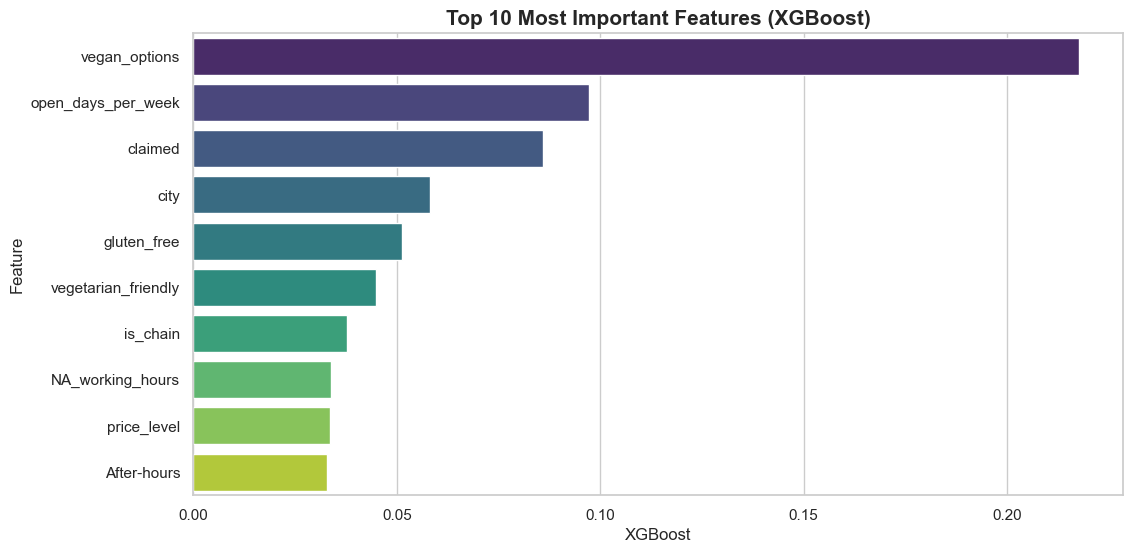

Feature Selection complete!


In [51]:
# 1. Initialize the models
# We use random_state for reproducibility
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
gb_model = GradientBoostingClassifier(random_state=42)
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# 2. Fit the models on our final encoded training data
print("Training models for feature importance...")
rf_model.fit(X_train_final, y_train)
gb_model.fit(X_train_final, y_train)
xgb_model.fit(X_train_final, y_train)

# 3. Extract importance into a DataFrame for comparison
features = X_train_final.columns
importance_df = pd.DataFrame({
    'Feature': features,
    'RandomForest': rf_model.feature_importances_,
    'GradientBoost': gb_model.feature_importances_,
    'XGBoost': xgb_model.feature_importances_
})

# 4. Create the 'selected' masks (as requested: importance > 0)
# This will give you a 1 if the feature has any predictive power, 0 otherwise
rf_selected  = (rf_model.feature_importances_ > 0).astype(int)
gb_selected  = (gb_model.feature_importances_ > 0).astype(int)
xgb_selected = (xgb_model.feature_importances_ > 0).astype(int)

# 5. Visualizing the Top 10 Features (using XGBoost as the main reference)
plt.figure(figsize=(12, 6))
top_10 = importance_df.sort_values(by='XGBoost', ascending=False).head(10)
sns.barplot(data=top_10, x='XGBoost', y='Feature', palette='viridis')
plt.title('Top 10 Most Important Features (XGBoost)', fontsize=15, fontweight='bold')
plt.show()

print("Feature Selection complete!")

C:\Users\Psychologist\AppData\Local\Temp\ipykernel_7392\3455612362.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=all_32, x='XGBoost', y='Feature', palette='viridis')


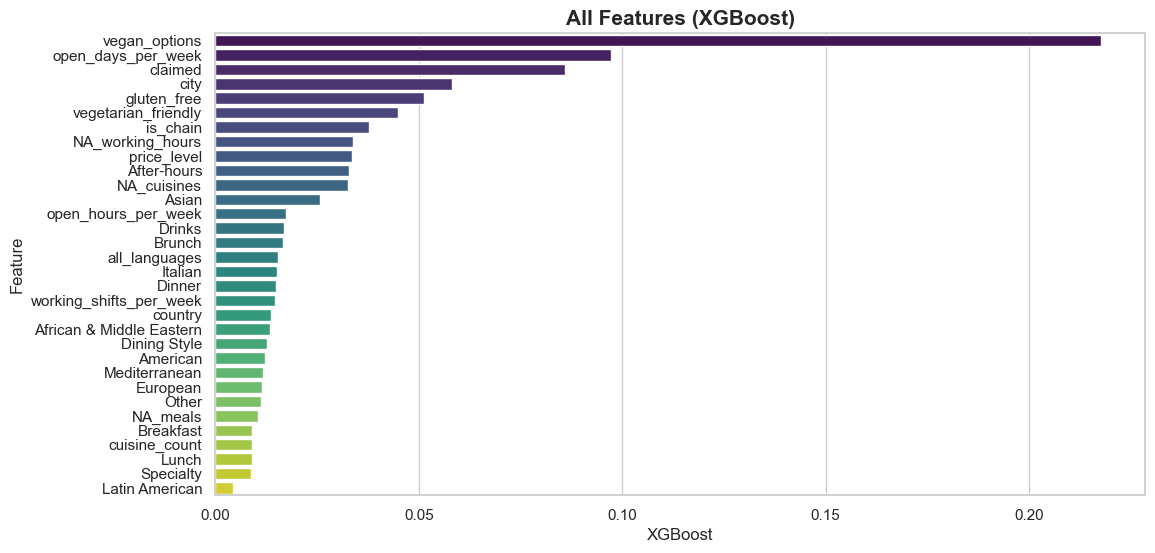

Feature Selection complete!


In [52]:
# 5. Visualizing all Features (using XGBoost as the main reference)
plt.figure(figsize=(12, 6))
all_32 = importance_df.sort_values(by='XGBoost', ascending=False).head(32)
sns.barplot(data=all_32, x='XGBoost', y='Feature', palette='viridis')
plt.title('All Features (XGBoost)', fontsize=15, fontweight='bold')
plt.show()

print("Feature Selection complete!")

In [53]:
# Create a DataFrame to store results
selection_df = pd.DataFrame({
    'Feature': X_train_final.columns,
    'GradientBoost': gb_selected,
    'RandomForest': rf_selected,
    'XGBoost': xgb_selected
})

In [54]:
# Sum the number of selections for each feature
selection_df['Sum'] = selection_df[['GradientBoost', 'RandomForest','XGBoost']].sum(axis=1)
selection_df.sort_values(by='Sum', ascending=False, inplace=True)

selection_df

,Feature,GradientBoost,RandomForest,XGBoost,Sum
0,city,1,1,1,3
1,country,1,1,1,3
2,African & Middle Eastern,1,1,1,3
3,American,1,1,1,3
4,Asian,1,1,1,3
5,Dining Style,1,1,1,3
6,European,1,1,1,3
7,Italian,1,1,1,3
9,Mediterranean,1,1,1,3
10,Other,1,1,1,3


## After checking the feature importance - we decided that every feature matters even if it doesn't look like it

## explanation: for example, 'latin_american' made from cuisine column and it encodes relevant dishes so we think it matters for that

## Training the models

In [55]:
def classificationMetrics(y, yhat):
    prf1 = metrics.precision_recall_fscore_support(y,yhat)
    res = {'Accuracy': metrics.accuracy_score(y,yhat),
           'Precision':prf1[0][1],
           'Recall': prf1[1][1],
           'f1-score': prf1[2][1],
           'AUC': metrics.roc_auc_score(y,yhat)
          }
    return res

## Decision Tree

In [56]:
model_1 = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state=42
)

model_1.fit(X_train_final, y_train)
pred1 = model_1.predict(X_dev_final)
metrics_model_1 = classificationMetrics(y_dev, pred1)
metrics_model_1

{'Accuracy': 0.6735019909869095,
 'Precision': np.float64(0.6563342318059299),
 'Recall': np.float64(0.36687157234978607),
 'f1-score': np.float64(0.47065872893149835),
 'AUC': 0.6205560418365358}

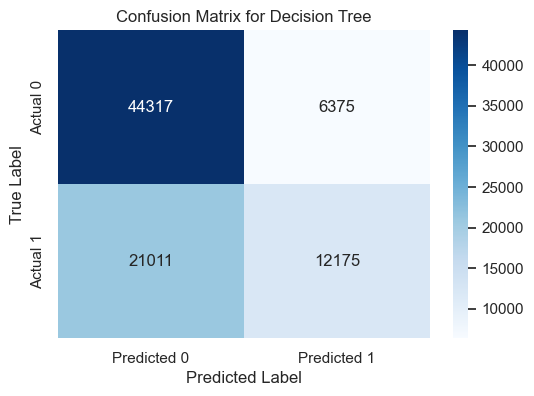

In [57]:
cm = metrics.confusion_matrix(y_dev, pred1)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Decision Tree')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Random Forest

In [58]:
model_2 = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

model_2.fit(X_train_final, y_train)
pred2 = model_2.predict(X_dev_final)
metrics_model_2 = classificationMetrics(y_dev, pred2)
metrics_model_2

{'Accuracy': 0.694019886024941,
 'Precision': np.float64(0.6697819314641744),
 'Recall': np.float64(0.44702585427589947),
 'f1-score': np.float64(0.5361886690159935),
 'AUC': 0.6513713663394015}

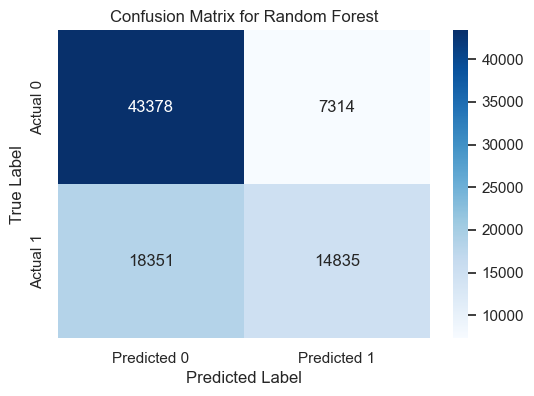

In [59]:
cm = metrics.confusion_matrix(y_dev, pred2)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Gradient Boosting

In [60]:
model_3 = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=20,
    subsample=0.8,
    random_state=42
)

model_3.fit(X_train_final, y_train)
pred3 = model_3.predict(X_dev_final)
metrics_model_3 = classificationMetrics(y_dev, pred3)
metrics_model_3

{'Accuracy': 0.6944848470397482,
 'Precision': np.float64(0.656146728354263),
 'Recall': np.float64(0.4786355692159344),
 'f1-score': np.float64(0.5535073352615256),
 'AUC': 0.6572140996083617}

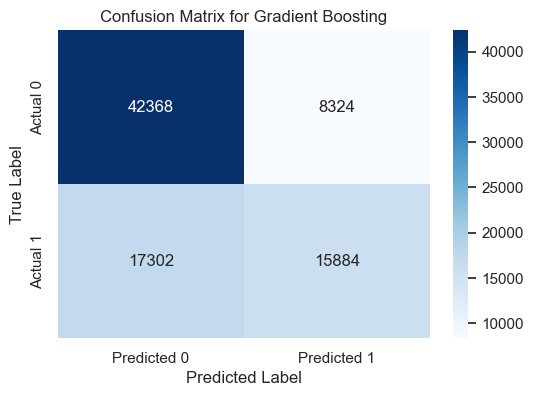

In [61]:
cm = metrics.confusion_matrix(y_dev, pred3)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Gradient Boosting')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## XG Boost

In [62]:
model_4 = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model_4.fit(X_train_final, y_train)
pred4 = model_4.predict(X_dev_final)
metrics_model_4 = classificationMetrics(y_dev, pred4)
metrics_model_4

d:\Documents\Eitan (PC)\Programing\DB Course\projects\Project 2\Tripadvisor ML project (03.2026)\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:26:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


{'Accuracy': 0.6936026133193448,
 'Precision': np.float64(0.6541471048513302),
 'Recall': np.float64(0.4786355692159344),
 'f1-score': np.float64(0.552794598733208),
 'AUC': 0.6564842013995715}

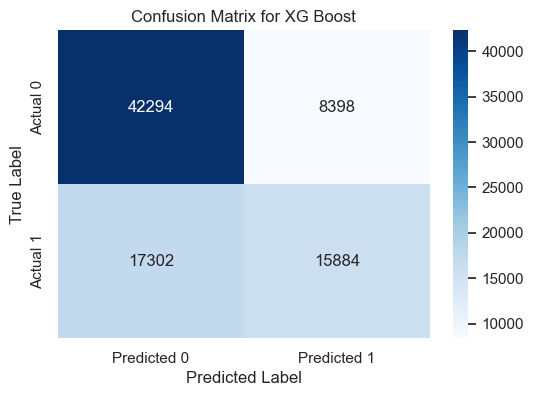

In [63]:
cm = metrics.confusion_matrix(y_dev, pred4)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for XG Boost')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Ada Boost


In [64]:
model_5 = AdaBoostClassifier(
    n_estimators=50,
    learning_rate=0.1,
    random_state=42
)

model_5.fit(X_train_final, y_train)
pred5 = model_5.predict(X_dev_final)
metrics_model_5 = classificationMetrics(y_dev, pred5)
metrics_model_5

{'Accuracy': 0.6595173943107847,
 'Precision': np.float64(0.660470278143858),
 'Recall': np.float64(0.28692822274453084),
 'f1-score': np.float64(0.4000588198222801),
 'AUC': 0.5951823312097152}

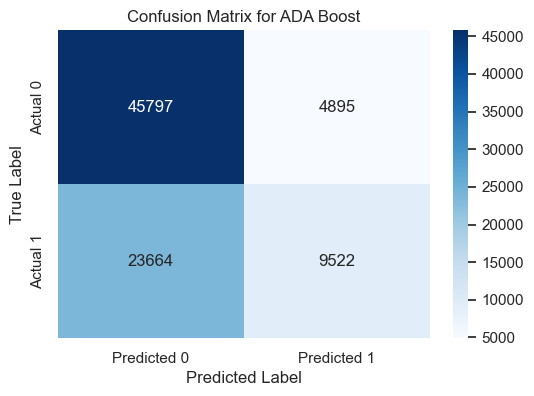

In [65]:
cm = metrics.confusion_matrix(y_dev, pred5)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for ADA Boost')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [66]:
# Create a list containing the metrics for each model
# We use the ** operator to unpack the metrics dictionary into the new dictionary
results_data = [
    {'Model': 'Decision Tree (Baseline)', **metrics_model_1},
    {'Model': 'Random Forest', **metrics_model_2},
    {'Model': 'HistGradient Boosting', **metrics_model_3},
    {'Model': 'XGBoost', **metrics_model_4},
    {'Model': 'AdaBoost', **metrics_model_5}
]

# Create the comparison DataFrame
comparison_df = pd.DataFrame(results_data)

# Set the Model name as the index for better readability
comparison_df.set_index('Model', inplace=True)

# Sort by a specific metric (e.g., F1-Score or Accuracy) to see the winner
# Assuming the metrics dictionary contains a key named 'f1' or 'accuracy'
# comparison_df = comparison_df.sort_values(by='f1', ascending=False)

# Print the final comparison table
print("Model Comparison Summary:")
display(comparison_df)

Model Comparison Summary:


,Accuracy,Precision,Recall,f1-score,AUC
Model,,,,,
Decision Tree (Baseline),0.673502,0.656334,0.366872,0.470659,0.620556
Random Forest,0.694020,0.669782,0.447026,0.536189,0.651371
HistGradient Boosting,0.694485,0.656147,0.478636,0.553507,0.657214
XGBoost,0.693603,0.654147,0.478636,0.552795,0.656484
AdaBoost,0.659517,0.660470,0.286928,0.400059,0.595182


## Random Forest -> the winner model based on our goal (high precision)

## Hyper-parameter tuning

In [1]:
# Define the broad parameter space
param_dist = {
    'max_depth': [10, 20, 30, 200],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [ 5, 10,15],
    'max_features': ['sqrt', 'log2', None]
}

# Initial model
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Step 1: Randomized Search to find the best neighborhood
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='precision',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_final, y_train)
print(f"Best params from RandomizedSearch: {random_search.best_params_}")


NameError: name 'RandomForestClassifier' is not defined

In [ ]:

# Step 2: Fine-tuning with GridSearchCV (example around found values)
# Assuming best_depth was 10 and best_n was 200
param_grid = {
    'max_depth': [8, 10, 12],
    'n_estimators': [180, 200, 220],
    'min_samples_split': [15, 20, 25]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='precision',
    n_jobs=-1
)

grid_search.fit(X_train_final, y_train)

In [ ]:
from google.colab import drive
import pandas as pd
import joblib
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define the path where you want to save the results
# Change 'My Drive/ML_Results' to your preferred folder
save_path = '/content/drive/MyDrive/ML_Results'
if not os.path.exists(save_path):
    os.makedirs(save_path)

# 3. Create a summary of the best parameters
best_results = {
    'Search_Type': ['RandomizedSearch', 'GridSearch'],
    'Best_Params': [str(random_search.best_params_), str(grid_search.best_params_)],
    'Best_Score_Precision': [random_search.best_score_, grid_search.best_score_]
}

best_params_df = pd.DataFrame(best_results)

# 4. Save best parameters to CSV
params_filename = os.path.join(save_path, 'rf_best_params_summary.csv')
best_params_df.to_csv(params_filename, index=False)

# 5. Optional: Save the full CV results (very useful for analysis)
cv_results_df = pd.DataFrame(grid_search.cv_results_)
cv_filename = os.path.join(save_path, 'rf_full_gridsearch_results.csv')
cv_results_df.to_csv(cv_filename, index=False)

# 6. Save the final best model
model_filename = os.path.join(save_path, 'best_rf_model.joblib')
joblib.dump(grid_search.best_estimator_, model_filename)

print(f"--- All results successfully saved to: {save_path} ---")

In [ ]:
# Run the model with best hyper-parameters
model_2 = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

model_2.fit(X_train_final, y_train)
pred2 = model_2.predict(X_dev_final)
metrics_model_2 = classificationMetrics(y_dev, pred2)
metrics_model_2

In [ ]:
# Check model performance compared to the train set (overfitting check)

# 1. Predict on both Train and Dev sets
train_preds = model_2.predict(X_train_final)
dev_preds = model_2.predict(X_dev_final)

# 2. Calculate metrics for both sets
metrics_train = classificationMetrics(y_train, train_preds)
metrics_dev = classificationMetrics(y_dev, dev_preds)

# 3. Create a comparison DataFrame for better visualization

comparison_results = pd.DataFrame({
    'Metric': metrics_train.keys(),
    'Train_Set': metrics_train.values(),
    'Dev_Set': metrics_dev.values()
})

# 4. Print the results
print("Performance Comparison: Train vs Dev")
print(comparison_results)

# Optional: Display the dictionaries directly if preferred
# print("\nTrain Metrics Dict:", metrics_train)
# print("Dev Metrics Dict:", metrics_dev)


## Treshold tuning

In [ ]:
# 1. Get probabilities for the positive class (class 1)
probs = model_2.predict_proba(X_dev_final)[:, 1]

# 2. Calculate data for ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_dev, probs)
roc_auc = auc(fpr, tpr)

# 3. Calculate data for Precision-Recall Curve
precision, recall, thresholds_pr = precision_recall_curve(y_dev, probs)
avg_precision = average_precision_score(y_dev, probs)

# 4. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot ROC Curve ---
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (1 - Specificity)')
ax1.set_ylabel('True Positive Rate (Recall)')
ax1.set_title('ROC Curve - Model 2 (Random Forest)')
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# --- Plot Precision-Recall Curve ---
ax2.plot(recall, precision, color='blue', lw=2, label=f'Avg Precision = {avg_precision:.2f}')
# Baseline is the proportion of positive samples in the data
baseline = sum(y_dev) / len(y_dev)
ax2.axhline(y=baseline, color='red', linestyle='--', label=f'Baseline ({baseline:.2f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve - Model 2 (Random Forest)')
ax2.legend(loc="upper right")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Find the threshold that gives at least 80% precision
target_precision = 0.8
indices = np.where(precision >= target_precision)[0]

if len(indices) > 0:
    # Get the last index where precision was above target
    idx = indices[0]
    # Note: threshold_pr has one less element than precision/recall
    chosen_threshold = thresholds_pr[idx]
    print(f"To get {target_precision*100}% Precision, use threshold: {chosen_threshold:.4f}")
    print(f"At this threshold, your Recall will be: {recall[idx]:.4f}")
else:
    print("Target precision not reachable with this model.")

In [ ]:
# Initialize the Random Forest model with provided hyperparameters
model_2 = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

# Fit the model on the finalized training data
model_2.fit(X_train_final, y_train)

# Define the custom threshold
custom_threshold = 0.6641

# Get probability estimates for the positive class (class 1)
# predict_proba returns [prob_class_0, prob_class_1]
probabilities = model_2.predict_proba(X_dev_final)[:, 1]

# Apply the custom threshold to generate predictions
# Samples with probability >= 0.6641 are classified as 1, otherwise 0
pred2 = (probabilities >= custom_threshold).astype(int)

# Calculate performance metrics using the custom predictions
metrics_model_2 = classificationMetrics(y_dev, pred2)

# Display the results
metrics_model_2

In [ ]:
cm = metrics.confusion_matrix(y_dev, pred2)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()